In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import scipy
import glob


In [37]:
df = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")
df

/tmp/ipykernel_89558/891687164.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")


<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

In [38]:
# Select surface soil layer only
var_tsoil = df["TSOI"]
var_soilm = df["H2OSOI"]
var_snowd = df["SNOW_DEPTH"]

In [39]:
var_tsoil

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [40]:
# Surface layer only (0.01m depth)
surface = var_tsoil.sel(levgrnd=slice(0.01,1.36))

# Or average over all layers
#profile_mean = var_tsoil.mean(dim="levsoi")

In [41]:
var_soilm.head()

<xarray.DataArray 'H2OSOI' (time: 5, levsoi: 5, lndgrid: 1)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * time     (time) object 40B 1995-01-01 00:00:00 ... 1995-01-05 00:00:00
  * levsoi   (levsoi) float32 20B 0.01 0.04 0.09 0.16 0.26
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

In [42]:
var_snowd.head()

<xarray.DataArray 'SNOW_DEPTH' (time: 5, lndgrid: 1)> Size: 20B
[5 values with dtype=float32]
Coordinates:
  * time     (time) object 40B 1995-01-01 00:00:00 ... 1995-01-05 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

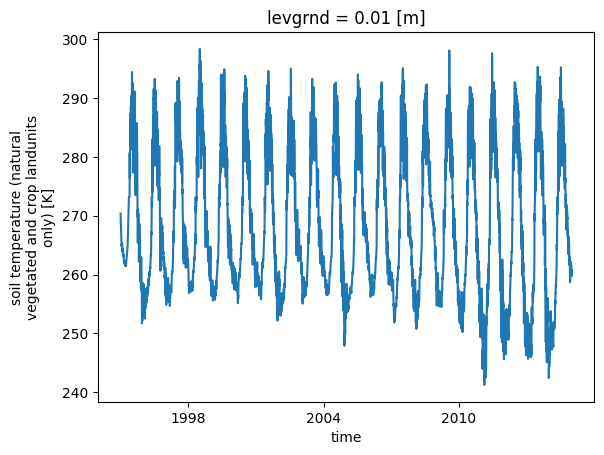

In [43]:
# Plot by layer
surface.isel(levgrnd=0).plot()
plt.show()

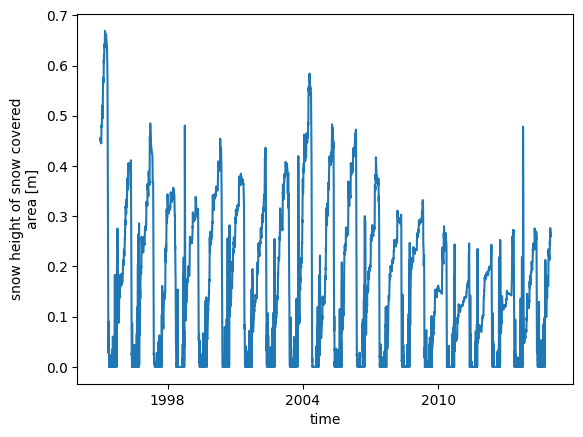

In [44]:
var_snowd.plot()
plt.show()

## Graphing observational plots

                           Value
Timestamp                       
2012-01-01 07:30:00+00:00  345.0
2012-01-01 08:00:00+00:00  346.0
2012-01-01 08:30:00+00:00  345.0
2012-01-01 09:00:00+00:00  345.0
2012-01-01 09:30:00+00:00  347.0
1620.0


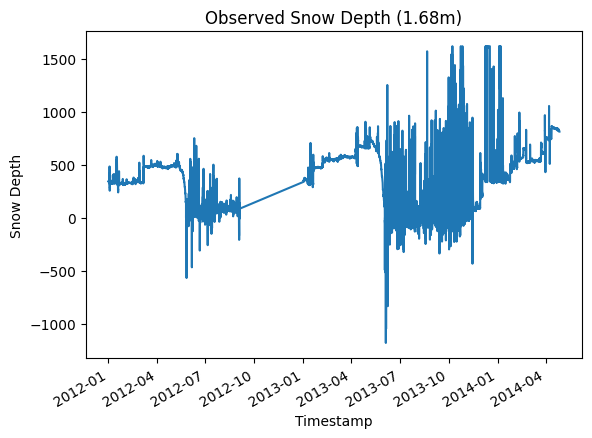

In [51]:
# Load observational data
obs = pd.read_csv(
    "TVC_obs/snow_depth/TVC_SnowDepth_1.68mSR50A.txt",   # just change the extension
    sep="\t",
    comment="#",
    parse_dates=["Timestamp"],
    index_col="Timestamp"
)

print(obs.head())

#seems theres some weird outliers every now and then
#obs = obs[obs["Value"] < 55]
print (obs["Value"].max())

obs["Value"].plot()
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth (1.68m)")
plt.show()

                           Value
Timestamp                       
2002-01-01 07:30:00+00:00  258.0
2002-01-01 08:00:00+00:00  256.0
2002-01-01 08:30:00+00:00  252.0
2002-01-01 09:00:00+00:00  250.0
2002-01-01 09:30:00+00:00  254.0
54.0


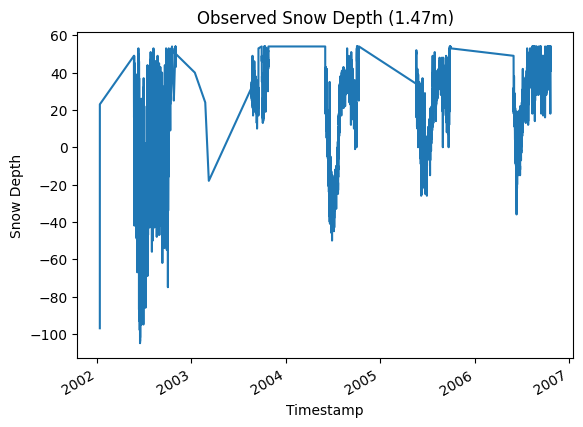

In [47]:
# Load observational data
obs = pd.read_csv(
    "TVC_obs/snow_depth/TVC_SnowDepth_1.47mSR50A.txt",   # just change the extension
    sep="\t",
    comment="#",
    parse_dates=["Timestamp"],
    index_col="Timestamp"
)

print(obs.head())

#seems theres some weird outliers every now and then
obs = obs[obs["Value"] < 55]
print (obs["Value"].max())

obs["Value"].plot()
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth (1.47m)")
plt.show()

## Time to combine

In [48]:
var_tsoil.head()

<xarray.DataArray 'TSOI' (time: 5, levgrnd: 5, lndgrid: 1)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * time     (time) object 40B 1995-01-01 00:00:00 ... 1995-01-05 00:00:00
  * levgrnd  (levgrnd) float32 20B 0.01 0.04 0.09 0.16 0.26
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

/tmp/ipykernel_89558/1651868.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
/tmp/ipykernel_89558/1651868.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


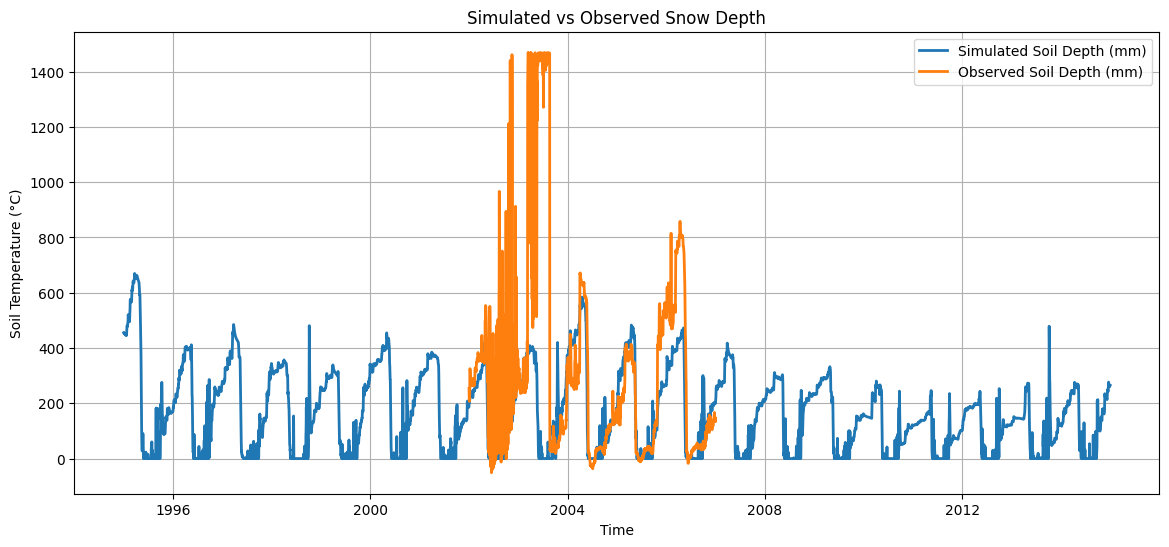

In [49]:
sim = var_snowd.copy()
sim['time'] = sim.indexes['time'].to_datetimeindex()

# Convert m → mm for plotting
sim_mm = sim * 1000

obs_df = pd.read_csv(
    "TVC_obs/snow_depth/TVC_SnowDepth_1.47mSR50A.txt",
    comment="#",
    sep=r"\s+|,|\t",
    engine="python"
)

obs_df.rename(columns={"Timestamp": "time", "Value": "obs_depth_mm"}, inplace=True)
obs_df["time"] = pd.to_datetime(obs_df["time"])

# Convert pandas → xarray
obs = obs_df.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Simulated
plt.plot(
    sim_mm["time"].values,
    sim_mm.values,
    label="Simulated Soil Depth (mm)",
    linewidth=2
)

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_depth_mm"].values,
    label="Observed Soil Depth (mm)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Temperature (°C)")
plt.title("Simulated vs Observed Snow Depth")
plt.grid(True)
plt.legend()
plt.show()

In [50]:
sim = var_tsoil.copy()
sim['time'] = sim.indexes['time'].to_datetimeindex()

# Convert K → °C for plotting
sim_C = sim - 273.15

obs_df = pd.read_csv(
    "TVC_soil_temp_10cm_2003-2014.txt",
    comment="#",
    sep=r"\s+|,|\t",
    engine="python"
)

obs_df.rename(columns={"Timestamp": "time", "Value": "obs_temp_C"}, inplace=True)
obs_df["time"] = pd.to_datetime(obs_df["time"])

# Convert pandas → xarray
obs = obs_df.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Simulated
plt.plot(
    sim_C["time"].values,
    sim_C.values,
    label="Simulated Soil Temp 10 cm (°C)",
    linewidth=2
)

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_temp_C"].values,
    label="Observed Soil Temp (Daily Mean, °C)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Temperature (°C)")
plt.title("Simulated vs Observed Soil Temperature")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_89558/1836596195.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
/tmp/ipykernel_89558/1836596195.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


FileNotFoundError: [Errno 2] No such file or directory: 'TVC_soil_temp_10cm_2003-2014.txt'